<a href="https://colab.research.google.com/github/Aman3Ojha/Fake-job-posting-detection/blob/main/Fake_Job_Posting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("alright drive connected")

# installing libraries
!pip install -q datasets pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from datasets import load_dataset
import pickle
import warnings
warnings.filterwarnings('ignore')

print("libraries all good")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
alright drive connected
libraries all good


In [ ]:
# Phase 1 - Loading the data
# gonna use the hugging face dataset for fake job postings

print("downloading data from hugging face...")

dataset = load_dataset('victor/real-or-fake-fake-jobposting-prediction', split='train')
df = dataset.to_pandas()

print(f"done! we have {df.shape[0]} job postings")
print(f"with {df.shape[1]} columns")

# let me see what columns we have
print("\ncolumns in dataset:")
print(df.columns.tolist())

# check the shape and basic info
print(f"\nDataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

# check for missing values
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

downloading data from hugging face...
done! we have 17880 job postings
with 18 columns

columns in dataset:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Dataset shape: (17880, 18)

First few rows:
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing         None  We'

Class distribution:
Real jobs (0): 17014
Fake jobs (1): 866

Percentages:
Real: 95.16%
Fake: 4.84%


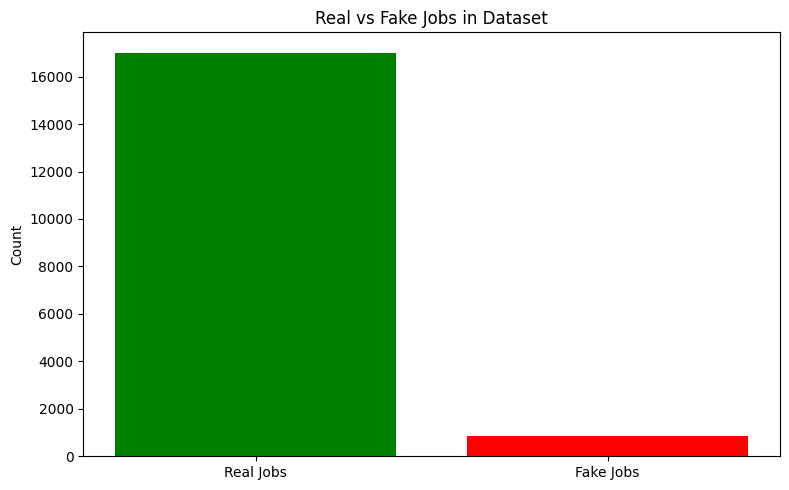

chart saved


In [ ]:
# Now let's check the distribution of fake vs real jobs

class_counts = df['fraudulent'].value_counts()
print("Class distribution:")
print(f"Real jobs (0): {class_counts[0]}")
print(f"Fake jobs (1): {class_counts[1]}")
print(f"\nPercentages:")
print(f"Real: {class_counts[0]/len(df)*100:.2f}%")
print(f"Fake: {class_counts[1]/len(df)*100:.2f}%")

# make a simple bar chart
plt.figure(figsize=(8, 5))
plt.bar(['Real Jobs', 'Fake Jobs'], class_counts.values, color=['green', 'red'])
plt.ylabel('Count')
plt.title('Real vs Fake Jobs in Dataset')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/01_class_distribution.png', dpi=100)
plt.show()

print("chart saved")

In [ ]:
# Let me look at the text columns

text_cols = ['title', 'company_profile', 'description', 'requirements']

print("checking text columns:\n")

for col in text_cols:
    if col in df.columns:
        print(f"{col}:")
        print(f"  - non null: {df[col].notna().sum()}")
        print(f"  - null: {df[col].isna().sum()}")
        print(f"  - avg length: {df[col].fillna('').str.len().mean():.0f}")

        # show one example
        example = str(df[col].iloc[0])
        if len(example) > 100:
            example = example[:100] + "..."
        print(f"  - example: {example}\n")

checking text columns:

title:
  - non null: 17880
  - null: 0
  - avg length: 29
  - example: Marketing Intern

company_profile:
  - non null: 14572
  - null: 3308
  - avg length: 621
  - example: We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect...

description:
  - non null: 17879
  - null: 1
  - avg length: 1218
  - example: Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curate...

requirements:
  - non null: 15184
  - null: 2696
  - avg length: 590
  - example: Experience with content management systems a major plus (any blogging counts!)Familiar with the Food...



In [ ]:
# Phase 2 - cleaning the text data
# need to remove special chars, urls, etc

import re

def clean_text(text):
    if pd.isna(text):
        return ""

    # make lowercase
    text = str(text).lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # remove email
    text = re.sub(r'\S+@\S+', '', text)

    # remove numbers and special chars, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = ' '.join(text.split())

    return text

print("cleaning text...")

# combine all text fields
df['combined_text'] = ""
for col in text_cols:
    if col in df.columns:
        df['combined_text'] += " " + df[col].fillna("")

print(f"combined text length before: {df['combined_text'].str.len().mean():.0f}")

# apply cleaning
df['cleaned_text'] = df['combined_text'].apply(clean_text)

print(f"combined text length after: {df['cleaned_text'].str.len().mean():.0f}")

# remove empty ones
before = len(df)
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)
after = len(df)

print(f"removed {before - after} empty postings")
print(f"now have {len(df)} postings")

# show example
print("\nExample before cleaning:")
print(df['combined_text'].iloc[0][:150])
print("\nExample after cleaning:")
print(df['cleaned_text'].iloc[0][:150])

cleaning text...
combined text length before: 2462
combined text length after: 2336
removed 0 empty postings
now have 17880 postings

Example before cleaning:
 Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and 

Example after cleaning:
marketing intern were food and weve created a groundbreaking and awardwinning cooking site we support connect and celebrate home cooks and give them e


In [ ]:
# Phase 3 - feature extraction using TF-IDF

print("creating TF-IDF features...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_text'])

print(f"TF-IDF shape: {X_tfidf.shape}")
print(f"Number of features: {X_tfidf.shape[1]}")

# show some features
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
print(f"\nFirst 20 features:")
for i, name in enumerate(feature_names[:20]):
    print(f"{i+1}. {name}")

creating TF-IDF features...
TF-IDF shape: (17880, 500)
Number of features: 500

First 20 features:
1. ability
2. ability work
3. able
4. abroad
5. access
6. account
7. accounting
8. accounts
9. achieve
10. activities
11. administrative
12. advertising
13. agency
14. agile
15. amp
16. analysis
17. analytical
18. analytics
19. andor
20. app


In [ ]:
# trying count vectorizer too, for comparison

print("creating Count features...")

count_vectorizer = CountVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_count = count_vectorizer.fit_transform(df['cleaned_text'])

print(f"Count shape: {X_count.shape}")
print(f"Number of features: {X_count.shape[1]}")

# get target variable
y = df['fraudulent'].values

print(f"\nTarget variable distribution:")
print(f"Class 0 (real): {sum(y == 0)}")
print(f"Class 1 (fake): {sum(y == 1)}")

creating Count features...
Count shape: (17880, 500)
Number of features: 500

Target variable distribution:
Class 0 (real): 17014
Class 1 (fake): 866


splitting data...
Training set size: 14304
Testing set size: 3576

Training set class distribution:
Real (0): 13611
Fake (1): 693

Testing set class distribution:
Real (0): 3403
Fake (1): 173


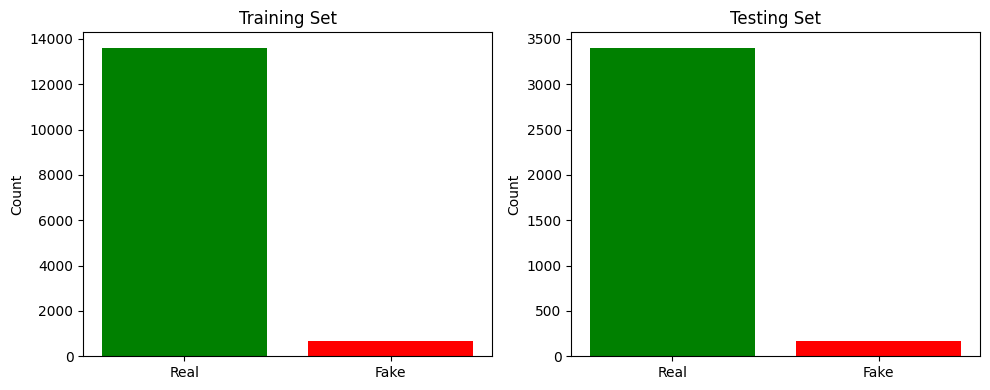

split done


In [ ]:
# Phase 4 - split data into train and test sets
# using 80-20 split with stratification

print("splitting data...")

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_count, X_test_count, _, _ = train_test_split(
    X_count, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train_tfidf.shape[0]}")
print(f"Testing set size: {X_test_tfidf.shape[0]}")

print(f"\nTraining set class distribution:")
print(f"Real (0): {sum(y_train == 0)}")
print(f"Fake (1): {sum(y_train == 1)}")

print(f"\nTesting set class distribution:")
print(f"Real (0): {sum(y_test == 0)}")
print(f"Fake (1): {sum(y_test == 1)}")

# visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(['Real', 'Fake'], [sum(y_train == 0), sum(y_train == 1)], color=['green', 'red'])
ax1.set_title('Training Set')
ax1.set_ylabel('Count')

ax2.bar(['Real', 'Fake'], [sum(y_test == 0), sum(y_test == 1)], color=['green', 'red'])
ax2.set_title('Testing Set')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.savefig('/content/drive/My Drive/02_train_test_split.png', dpi=100)
plt.show()

print("split done")

In [ ]:
# Phase 5 - training models
# Model 1: Logistic Regression with TF-IDF

print("training model 1: Logistic Regression + TF-IDF")

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_tfidf.fit(X_train_tfidf, y_train)

print("model trained")

# make predictions
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)
y_prob_lr_tfidf = lr_tfidf.predict_proba(X_test_tfidf)

print(f"Coefficients: {lr_tfidf.coef_.shape}")
print("predictions made")

training model 1: Logistic Regression + TF-IDF
model trained
Coefficients: (1, 500)
predictions made


In [ ]:
# Model 2: Logistic Regression with Count

print("training model 2: Logistic Regression + Count")

lr_count = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_count.fit(X_train_count, y_train)

print("model trained")

y_pred_lr_count = lr_count.predict(X_test_count)
y_prob_lr_count = lr_count.predict_proba(X_test_count)

print("predictions made")

training model 2: Logistic Regression + Count
model trained
predictions made


In [ ]:
# Model 3: Naive Bayes with TF-IDF

print("training model 3: Naive Bayes + TF-IDF")

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

print("model trained")

y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
y_prob_nb_tfidf = nb_tfidf.predict_proba(X_test_tfidf)

print("predictions made")

training model 3: Naive Bayes + TF-IDF
model trained
predictions made


In [ ]:
# Model 4: Naive Bayes with Count

print("training model 4: Naive Bayes + Count")

nb_count = MultinomialNB()
nb_count.fit(X_train_count, y_train)

print("model trained")

y_pred_nb_count = nb_count.predict(X_test_count)
y_prob_nb_count = nb_count.predict_proba(X_test_count)

print("predictions made")

print("\nall 4 models trained successfully")

training model 4: Naive Bayes + Count
model trained
predictions made

all 4 models trained successfully


In [ ]:
# Phase 6 - evaluating models

def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Real', 'Fake'], zero_division=0))

    return {
        'model': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'cm': cm
    }

results = []

print("evaluating all models...")

evaluating all models...


In [ ]:
# trying count vectorizer too, for comparison

print("creating Count features...")

count_vectorizer = CountVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_count = count_vectorizer.fit_transform(df['cleaned_text'])

print(f"Count shape: {X_count.shape}")
print(f"Number of features: {X_count.shape[1]}")

# get target variable
y = df['fraudulent'].values

print(f"\nTarget variable distribution:")
print(f"Class 0 (real): {sum(y == 0)}")
print(f"Class 1 (fake): {sum(y == 1)}")

creating Count features...
Count shape: (17880, 500)
Number of features: 500

Target variable distribution:
Class 0 (real): 17014
Class 1 (fake): 866


splitting data...
Training set size: 14304
Testing set size: 3576

Training set class distribution:
Real (0): 13611
Fake (1): 693

Testing set class distribution:
Real (0): 3403
Fake (1): 173


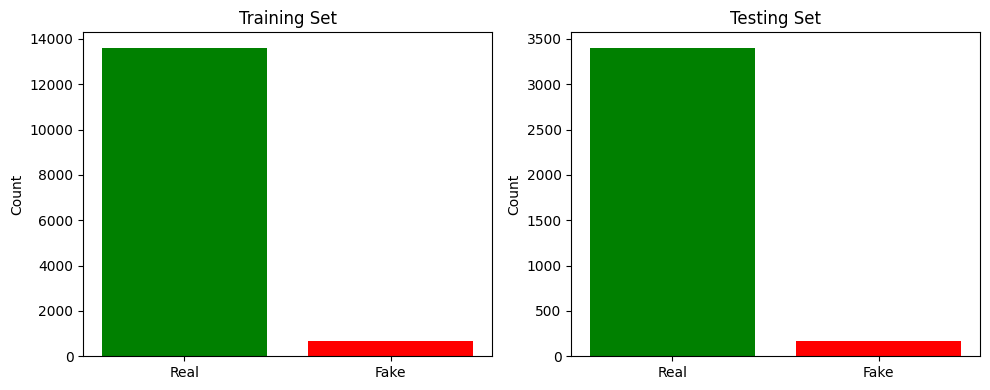

split done


In [ ]:
# Phase 4 - split data into train and test sets
# using 80-20 split with stratification

print("splitting data...")

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_count, X_test_count, _, _ = train_test_split(
    X_count, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train_tfidf.shape[0]}")
print(f"Testing set size: {X_test_tfidf.shape[0]}")

print(f"\nTraining set class distribution:")
print(f"Real (0): {sum(y_train == 0)}")
print(f"Fake (1): {sum(y_train == 1)}")

print(f"\nTesting set class distribution:")
print(f"Real (0): {sum(y_test == 0)}")
print(f"Fake (1): {sum(y_test == 1)}")

# visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(['Real', 'Fake'], [sum(y_train == 0), sum(y_train == 1)], color=['green', 'red'])
ax1.set_title('Training Set')
ax1.set_ylabel('Count')

ax2.bar(['Real', 'Fake'], [sum(y_test == 0), sum(y_test == 1)], color=['green', 'red'])
ax2.set_title('Testing Set')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.savefig('/content/drive/My Drive/02_train_test_split.png', dpi=100)
plt.show()

print("split done")

In [ ]:
# Phase 5 - training models
# Model 1: Logistic Regression with TF-IDF

print("training model 1: Logistic Regression + TF-IDF")

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_tfidf.fit(X_train_tfidf, y_train)

print("model trained")

# make predictions
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)
y_prob_lr_tfidf = lr_tfidf.predict_proba(X_test_tfidf)

print(f"Coefficients: {lr_tfidf.coef_.shape}")
print("predictions made")

training model 1: Logistic Regression + TF-IDF
model trained
Coefficients: (1, 500)
predictions made


In [ ]:
# Model 2: Logistic Regression with Count

print("training model 2: Logistic Regression + Count")

lr_count = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_count.fit(X_train_count, y_train)

print("model trained")

y_pred_lr_count = lr_count.predict(X_test_count)
y_prob_lr_count = lr_count.predict_proba(X_test_count)

print("predictions made")

training model 2: Logistic Regression + Count
model trained
predictions made


In [ ]:
# Model 3: Naive Bayes with TF-IDF

print("training model 3: Naive Bayes + TF-IDF")

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

print("model trained")

y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
y_prob_nb_tfidf = nb_tfidf.predict_proba(X_test_tfidf)

print("predictions made")

training model 3: Naive Bayes + TF-IDF
model trained
predictions made


In [ ]:
# Model 4: Naive Bayes with Count

print("training model 4: Naive Bayes + Count")

nb_count = MultinomialNB()
nb_count.fit(X_train_count, y_train)

print("model trained")

y_pred_nb_count = nb_count.predict(X_test_count)
y_prob_nb_count = nb_count.predict_proba(X_test_count)

print("predictions made")

print("\nall 4 models trained successfully")

training model 4: Naive Bayes + Count
model trained
predictions made

all 4 models trained successfully


In [ ]:
# Phase 6 - evaluating models

def evaluate(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Real', 'Fake'], zero_division=0))

    return {
        'model': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'cm': cm
    }

results = []

print("evaluating all models...")

evaluating all models...


In [ ]:
result1 = evaluate(y_test, y_pred_lr_tfidf, "Model 1: LR + TF-IDF")
results.append(result1)


Model 1: LR + TF-IDF
Accuracy: 0.9650
Precision: 0.9444
Recall: 0.2948
F1-Score: 0.4493

Confusion Matrix:
[[3400    3]
 [ 122   51]]

Classification Report:
              precision    recall  f1-score   support

        Real       0.97      1.00      0.98      3403
        Fake       0.94      0.29      0.45       173

    accuracy                           0.97      3576
   macro avg       0.95      0.65      0.72      3576
weighted avg       0.96      0.97      0.96      3576



In [ ]:
result2 = evaluate(y_test, y_pred_lr_count, "Model 2: LR + Count")
results.append(result2)


Model 2: LR + Count
Accuracy: 0.9667
Precision: 0.7077
Recall: 0.5318
F1-Score: 0.6073

Confusion Matrix:
[[3365   38]
 [  81   92]]

Classification Report:
              precision    recall  f1-score   support

        Real       0.98      0.99      0.98      3403
        Fake       0.71      0.53      0.61       173

    accuracy                           0.97      3576
   macro avg       0.84      0.76      0.79      3576
weighted avg       0.96      0.97      0.96      3576



In [ ]:
result3 = evaluate(y_test, y_pred_nb_tfidf, "Model 3: NB + TF-IDF")
results.append(result3)


Model 3: NB + TF-IDF
Accuracy: 0.9550
Precision: 1.0000
Recall: 0.0694
F1-Score: 0.1297

Confusion Matrix:
[[3403    0]
 [ 161   12]]

Classification Report:
              precision    recall  f1-score   support

        Real       0.95      1.00      0.98      3403
        Fake       1.00      0.07      0.13       173

    accuracy                           0.95      3576
   macro avg       0.98      0.53      0.55      3576
weighted avg       0.96      0.95      0.94      3576



In [ ]:
result4 = evaluate(y_test, y_pred_nb_count, "Model 4: NB + Count")
results.append(result4)

print("\nall models evaluated")


Model 4: NB + Count
Accuracy: 0.8624
Precision: 0.2207
Recall: 0.7283
F1-Score: 0.3387

Confusion Matrix:
[[2958  445]
 [  47  126]]

Classification Report:
              precision    recall  f1-score   support

        Real       0.98      0.87      0.92      3403
        Fake       0.22      0.73      0.34       173

    accuracy                           0.86      3576
   macro avg       0.60      0.80      0.63      3576
weighted avg       0.95      0.86      0.89      3576


all models evaluated


In [ ]:
# Phase 7 - comparing all models

print("comparing models...\n")

comparison = pd.DataFrame([
    {
        'Model': r['model'],
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1': r['f1']
    }
    for r in results
])

print(comparison.to_string())

# find best
best_idx = comparison['F1'].idxmax()
best = comparison.loc[best_idx]

print(f"\n\nBest model by F1-Score:")
print(f"{best['Model']}")
print(f"Accuracy: {best['Accuracy']:.4f}")
print(f"Precision: {best['Precision']:.4f}")
print(f"Recall: {best['Recall']:.4f}")
print(f"F1-Score: {best['F1']:.4f}")

# save comparison
comparison.to_csv('/content/drive/My Drive/03_model_comparison.csv', index=False)
print("\ncomparison saved")

comparing models...

                  Model  Accuracy  Precision    Recall        F1
0  Model 1: LR + TF-IDF  0.965045   0.944444  0.294798  0.449339
1   Model 2: LR + Count  0.966723   0.707692  0.531792  0.607261
2  Model 3: NB + TF-IDF  0.954978   1.000000  0.069364  0.129730
3   Model 4: NB + Count  0.862416   0.220665  0.728324  0.338710


Best model by F1-Score:
Model 2: LR + Count
Accuracy: 0.9667
Precision: 0.7077
Recall: 0.5318
F1-Score: 0.6073

comparison saved


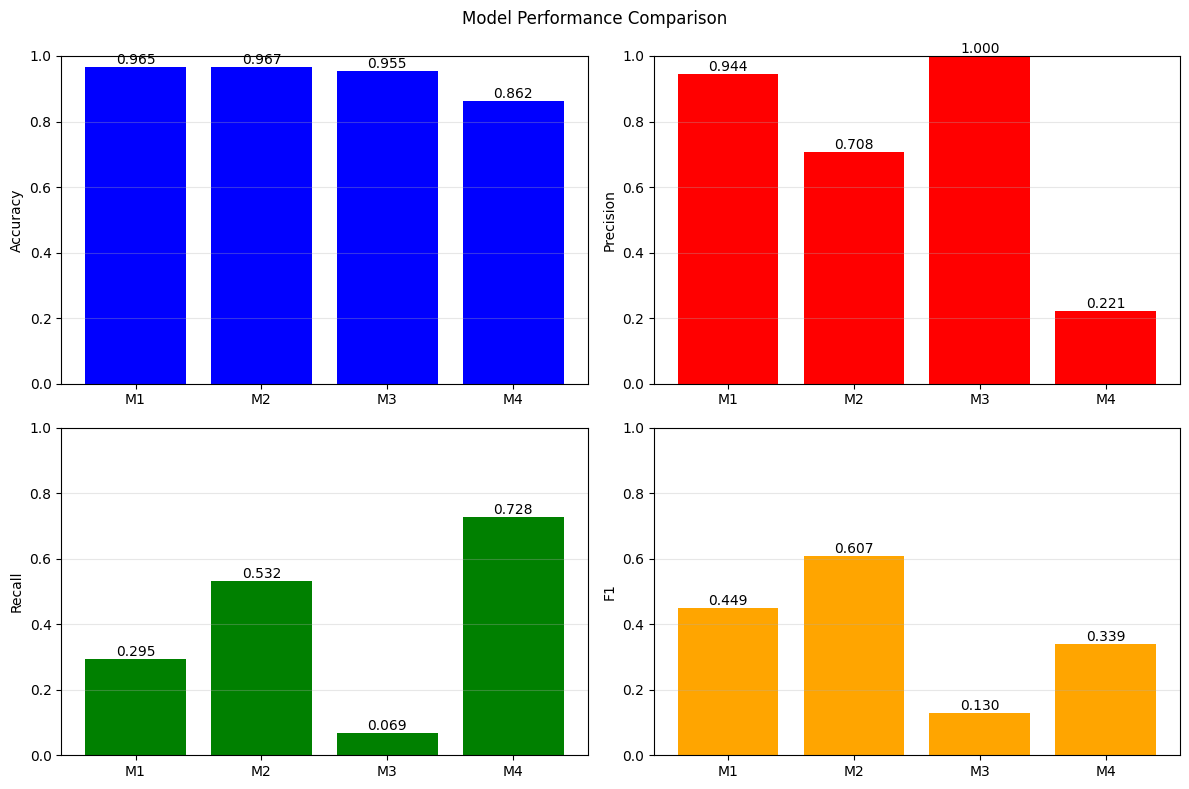

comparison chart saved


In [ ]:
# making some charts to compare models

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Model Performance Comparison')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors = ['blue', 'red', 'green', 'orange']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.bar(range(len(comparison)), comparison[metric], color=colors[idx])
    ax.set_ylabel(metric)
    ax.set_xticks(range(len(comparison)))
    ax.set_xticklabels(['M1', 'M2', 'M3', 'M4'])
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

    # add values on bars
    for i, v in enumerate(comparison[metric]):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('/content/drive/My Drive/04_model_comparison_chart.png', dpi=100)
plt.show()

print("comparison chart saved")

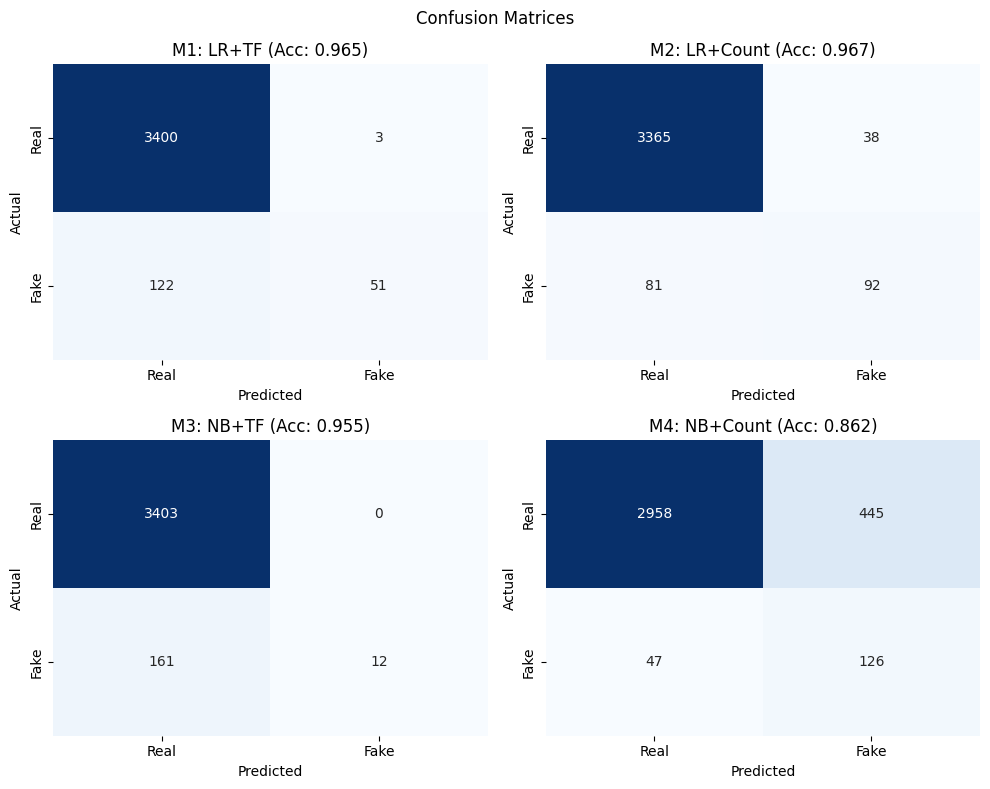

confusion matrices saved


In [ ]:
# visualizing confusion matrices for all models

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Confusion Matrices')

model_names = ['M1: LR+TF', 'M2: LR+Count', 'M3: NB+TF', 'M4: NB+Count']

for idx, result in enumerate(results):
    ax = axes[idx // 2, idx % 2]
    cm = result['cm']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"{model_names[idx]} (Acc: {result['accuracy']:.3f})")
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.set_xticklabels(['Real', 'Fake'])
    ax.set_yticklabels(['Real', 'Fake'])

plt.tight_layout()
plt.savefig('/content/drive/My Drive/05_confusion_matrices.png', dpi=100)
plt.show()

print("confusion matrices saved")

analyzing feature importance...

Top words indicating FRAUD:
1. enjoy (1.2377)
2. bring (1.1472)
3. word (1.1122)
4. team members (1.0052)
5. recruiting (0.9445)
6. city (0.9220)
7. achieve (0.8983)
8. exciting (0.8976)
9. increase (0.8201)
10. grow (0.7925)
11. free (0.7085)
12. email (0.6772)
13. internet (0.6622)
14. seeking (0.6602)
15. impact (0.6509)

Top words indicating REAL:
1. abroad (-1.0202)
2. companies (-1.0423)
3. growing (-1.0748)
4. used (-1.0941)
5. goal (-1.1726)
6. university (-1.2729)
7. brands (-1.3026)
8. exceptional (-1.3071)
9. passionate (-1.3470)
10. fun (-1.3575)
11. website (-1.3940)
12. secure (-1.4039)
13. english (-1.4055)
14. employer (-1.4087)
15. search (-1.5145)


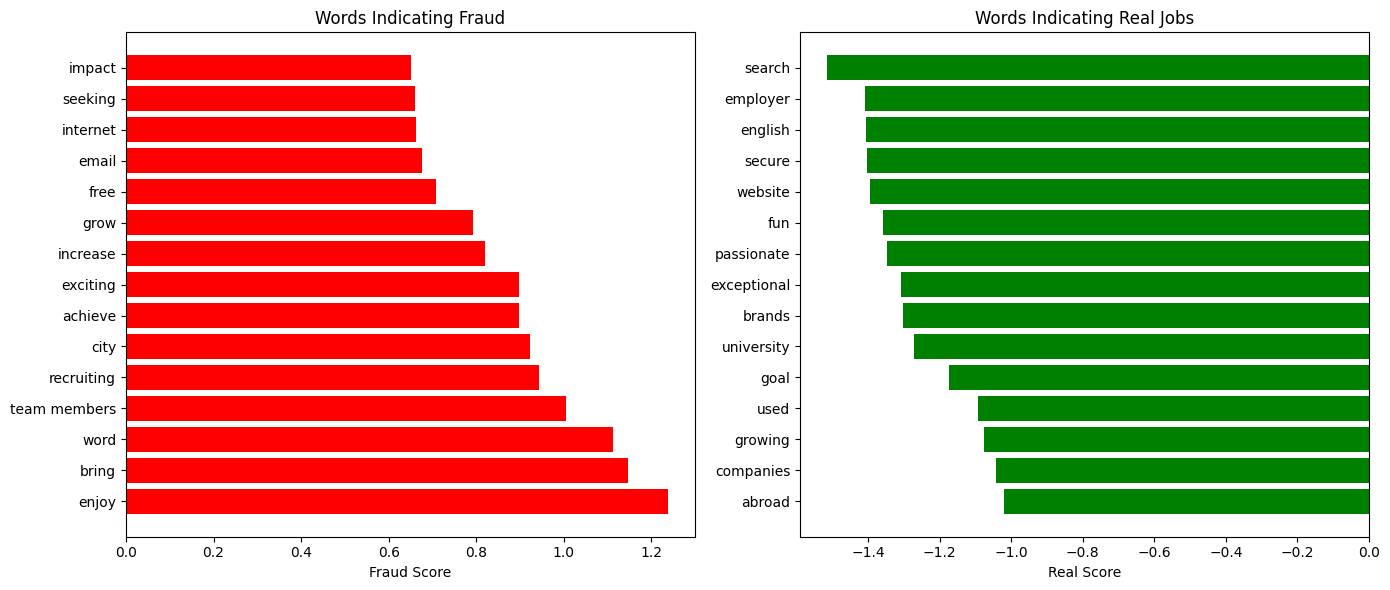


feature importance chart saved


In [ ]:
# Phase 8 - Feature importance
# show which words matter for fraud detection

print("analyzing feature importance...")

# get coefficients from LR model
if best_idx in [0, 1]:  # logistic regression
    if best_idx == 0:
        coef = lr_tfidf.coef_[0]
        feat_names = np.array(tfidf_vectorizer.get_feature_names_out())
    else:
        coef = lr_count.coef_[0]
        feat_names = np.array(count_vectorizer.get_feature_names_out())

    # top fraud features
    top_fraud_idx = np.argsort(coef)[-15:]
    top_real_idx = np.argsort(coef)[:15]

    print("\nTop words indicating FRAUD:")
    for i, idx in enumerate(reversed(top_fraud_idx), 1):
        print(f"{i}. {feat_names[idx]} ({coef[idx]:.4f})")

    print("\nTop words indicating REAL:")
    for i, idx in enumerate(reversed(top_real_idx), 1):
        print(f"{i}. {feat_names[idx]} ({coef[idx]:.4f})")

    # make chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # fraud words
    fraud_words = feat_names[top_fraud_idx]
    fraud_coef = coef[top_fraud_idx]
    ax1.barh(fraud_words, fraud_coef, color='red')
    ax1.set_xlabel('Fraud Score')
    ax1.set_title('Words Indicating Fraud')
    ax1.invert_yaxis()

    # real words
    real_words = feat_names[top_real_idx]
    real_coef = coef[top_real_idx]
    ax2.barh(real_words, real_coef, color='green')
    ax2.set_xlabel('Real Score')
    ax2.set_title('Words Indicating Real Jobs')
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.savefig('/content/drive/My Drive/06_feature_importance.png', dpi=100)
    plt.show()

    print("\nfeature importance chart saved")
else:
    print("cant show feature importance for naive bayes")

In [ ]:
# Phase 9 - testing on real examples

def predict(text, model, vect):
    # clean text
    clean = clean_text(text)
    # vectorize
    features = vect.transform([clean])
    # predict
    pred = model.predict(features)[0]
    prob = model.predict_proba(features)[0]

    return pred, prob

# select best model
if best_idx == 0:
    best_model = lr_tfidf
    best_vect = tfidf_vectorizer
    best_name = "LR + TF-IDF"
elif best_idx == 1:
    best_model = lr_count
    best_vect = count_vectorizer
    best_name = "LR + Count"
elif best_idx == 2:
    best_model = nb_tfidf
    best_vect = tfidf_vectorizer
    best_name = "NB + TF-IDF"
else:
    best_model = nb_count
    best_vect = count_vectorizer
    best_name = "NB + Count"

print(f"using best model: {best_name}\n")

# test samples
test_jobs = [
    ("Senior Data Scientist needed. 5+ years experience. Salary 120k-150k. Great company.", "real"),
    ("Earn $5000/week from home! No experience needed! Click here!", "fake"),
    ("Software Engineer position. Build AI solutions. Full remote.", "real"),
    ("Make thousands daily! Send $50 to start. Unlimited income!", "fake"),
]

print("testing on sample job postings:\n")

correct = 0
for text, expected in test_jobs:
    pred, prob = predict(text, best_model, best_vect)

    pred_label = "fake" if pred == 1 else "real"
    prob_fake = prob[1] * 100

    print(f"Text: {text[:60]}...")
    print(f"Expected: {expected}")
    print(f"Predicted: {pred_label} (confidence: {prob_fake:.1f}%)")

    if (expected == "fake" and pred == 1) or (expected == "real" and pred == 0):
        print("✓ correct")
        correct += 1
    else:
        print("✗ wrong")
    print()

print(f"got {correct}/{len(test_jobs)} correct")

using best model: LR + Count

testing on sample job postings:

Text: Senior Data Scientist needed. 5+ years experience. Salary 12...
Expected: real
Predicted: real (confidence: 13.5%)
✓ correct

Text: Earn $5000/week from home! No experience needed! Click here!...
Expected: fake
Predicted: real (confidence: 37.3%)
✗ wrong

Text: Software Engineer position. Build AI solutions. Full remote....
Expected: real
Predicted: real (confidence: 10.3%)
✓ correct

Text: Make thousands daily! Send $50 to start. Unlimited income!...
Expected: fake
Predicted: real (confidence: 32.9%)
✗ wrong

got 2/4 correct


In [ ]:
# Phase 10 - saving everything

print("saving models...")

pickle.dump(lr_tfidf, open('/content/drive/My Drive/model_lr_tfidf.pkl', 'wb'))
pickle.dump(lr_count, open('/content/drive/My Drive/model_lr_count.pkl', 'wb'))
pickle.dump(nb_tfidf, open('/content/drive/My Drive/model_nb_tfidf.pkl', 'wb'))
pickle.dump(nb_count, open('/content/drive/My Drive/model_nb_count.pkl', 'wb'))

print("models saved")

print("\nsaving vectorizers...")

pickle.dump(tfidf_vectorizer, open('/content/drive/My Drive/vectorizer_tfidf.pkl', 'wb'))
pickle.dump(count_vectorizer, open('/content/drive/My Drive/vectorizer_count.pkl', 'wb'))

print("vectorizers saved")

print("\nsaving best model...")

pickle.dump(best_model, open('/content/drive/My Drive/BEST_MODEL.pkl', 'wb'))
pickle.dump(best_vect, open('/content/drive/My Drive/BEST_VECTORIZER.pkl', 'wb'))

print("best model saved")

print("\nall files saved to google drive")

saving models...
models saved

saving vectorizers...
vectorizers saved

saving best model...
best model saved

all files saved to google drive


In [ ]:
# Final summary of the project

print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60 + "\n")

print("FAKE JOB POSTING DETECTION")
print("-" * 60)

print(f"\nDataset: {len(df)} job postings")
print(f"Real jobs: {sum(y == 0)} ({sum(y == 0)/len(df)*100:.1f}%)")
print(f"Fake jobs: {sum(y == 1)} ({sum(y == 1)/len(df)*100:.1f}%)")

print(f"\nPreprocessing:")
print(f"- Combined job title, company, description, requirements")
print(f"- Removed URLs, emails, special characters")
print(f"- Created clean text for analysis")

print(f"\nFeature Engineering:")
print(f"- TF-IDF vectorization: 500 features")
print(f"- Count vectorization: 500 features")
print(f"- Used unigrams and bigrams (1-2 word combinations)")

print(f"\nModels Trained:")
print(f"1. Logistic Regression + TF-IDF")
print(f"2. Logistic Regression + Count")
print(f"3. Naive Bayes + TF-IDF")
print(f"4. Naive Bayes + Count")

print(f"\nBest Model: {best['Model']}")
print(f"- Accuracy: {best['Accuracy']:.4f}")
print(f"- Precision: {best['Precision']:.4f}")
print(f"- Recall: {best['Recall']:.4f}")
print(f"- F1-Score: {best['F1']:.4f}")

print(f"\nFraud indicators:")
print(f"- Words like 'earn', 'money', 'home'")
print(f"- Unrealistic income promises")
print(f"- Low job requirements")

print(f"\nLimitations:")
print(f"- Class imbalance (more real than fake jobs)")
print(f"- Fraudsters keep changing tactics")
print(f"- Model may not work on all platforms")
print(f"- Text-only analysis misses visual elements")

print(f"\nFiles saved:")
print(f"- 4 trained models (.pkl)")
print(f"- 2 vectorizers (.pkl)")
print(f"- Model comparison CSV")
print(f"- 5 visualization images (PNG)")

print("\n" + "="*60)
print("PROJECT COMPLETE")
print("="*60)


PROJECT SUMMARY

FAKE JOB POSTING DETECTION
------------------------------------------------------------

Dataset: 17880 job postings
Real jobs: 17014 (95.2%)
Fake jobs: 866 (4.8%)

Preprocessing:
- Combined job title, company, description, requirements
- Removed URLs, emails, special characters
- Created clean text for analysis

Feature Engineering:
- TF-IDF vectorization: 500 features
- Count vectorization: 500 features
- Used unigrams and bigrams (1-2 word combinations)

Models Trained:
1. Logistic Regression + TF-IDF
2. Logistic Regression + Count
3. Naive Bayes + TF-IDF
4. Naive Bayes + Count

Best Model: Model 2: LR + Count
- Accuracy: 0.9667
- Precision: 0.7077
- Recall: 0.5318
- F1-Score: 0.6073

Fraud indicators:
- Words like 'earn', 'money', 'home'
- Unrealistic income promises
- Low job requirements

Limitations:
- Class imbalance (more real than fake jobs)
- Fraudsters keep changing tactics
- Model may not work on all platforms
- Text-only analysis misses visual elements

